【Python セミナー 第2回 予習】  
#* の横に、このコードはどのような役割をになっているか簡単に記載してください。  
必要に応じてライブラリを追加してください。

In [2]:
#* このセルでは、この後の分析で使う道具をまとめて読み込んでいます。Pythonでは、便利な機能を使う前にimportで準備しておく必要があります。
#* NumPyは、数字の計算をしやすくするためのライブラリです。ここでは平均、標準偏差、平方根などの計算に使います。
import numpy as np
#* pandasは、Excelの表のようなデータをPythonで扱うためのライブラリです。CSVファイルを読み込んだり、列を選んだり、不要な列を消したりできます。
import pandas as pd
#* scatter_matrixは、データの中にある複数の項目どうしの関係を、散布図としてまとめて確認したいときに使う関数です。
from pandas.plotting import scatter_matrix
#* matplotlib.pyplotは、グラフを描くための基本的なライブラリです。今回のように実測値と予測値を散布図で比べるときに使います。
import matplotlib.pyplot as plt
#* matplotlib.figureは、グラフを表示するための大きな枠を扱う機能です。グラフのサイズや全体の見た目を調整するときに使います。
import matplotlib.figure as figure
#* rcParamsは、グラフ全体の共通設定を変えるためのものです。たとえば文字の大きさ、線の太さ、図の表示スタイルなどをまとめて設定できます。
from matplotlib import rcParams
#* sklearn.metricsは、機械学習モデルの予測がどれくらい正しいかを調べるための機能です。予測値と実際の値の差を数値で確認できます。
from sklearn import metrics
#* train_test_splitは、データを「学習用」と「テスト用」に分ける関数です。cross_val_predictは、データの分け方を変えながら予測を試す関数です。RandomizedSearchCVとGridSearchCVは、モデルの設定をいくつか試して、よい設定を探すための関数です。
from sklearn.model_selection import train_test_split, cross_val_predict, RandomizedSearchCV, GridSearchCV
#* permutation_importanceは、どの説明変数が予測にどれくらい役立っているかを調べるための関数です。重要な項目ほど、予測結果への影響が大きくなります。
from sklearn.inspection import permutation_importance
#* seabornは、見やすいグラフを簡単に作るためのライブラリです。matplotlibを使いやすくしたものだと考えると分かりやすいです。
import seaborn as sns
#* mean_squared_error、mean_absolute_error、r2_scoreは、予測がどれくらい実際の値に近いかを評価するための関数です。MSEやMAEは小さいほどよく、R2は1に近いほどよい予測です。
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#* xgboostは、XGBoostという機械学習モデルを使うためのライブラリです。たくさんの小さな判断ルールを組み合わせて、数値を予測するのが得意です。
import xgboost as xgb
#* EarlyStoppingは、学習を続けても予測性能があまり良くならなくなったときに、自動で学習を止めるための機能です。学習しすぎを防ぐために使います。
from xgboost.callback import EarlyStopping
#*
from sklearn import linear_model

In [3]:
#* この関数は、作ったモデルの予測がどれくらい正確かを確認するためのものです。数値の評価結果を表示し、さらに実際の値と予測した値をグラフで比べます。
def pred_plot(train_targets,train_predictions,test_targets,test_predictions,model_name):
    #* まず、学習に使ったデータに対する予測結果を評価します。ここでは、実際の値と予測値のずれの大きさや、当てはまりの良さを計算しています。
    train_mse = mean_squared_error(train_targets, train_predictions)
    train_mae = mean_absolute_error(train_targets, train_predictions)
    train_r2 = r2_score(train_targets, train_predictions)
    train_rmse = np.sqrt(train_mse)

    #* 次に、学習には使っていないテストデータに対する予測結果を評価します。こちらの結果を見ることで、初めて見るデータにも対応できているかを確認できます。
    test_mse = mean_squared_error(test_targets, test_predictions)
    test_mae = mean_absolute_error(test_targets, test_predictions)
    test_r2 = r2_score(test_targets, test_predictions)
    test_rmse = np.sqrt(test_mse)

    print(f'\nMEGAN Training Set Performance:')
    print(f'Samples: {len(train_predictions)} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R²: {train_r2:.4f}')

    print(f'\nMEGAN Test Set Performance:')
    print(f'Samples: {len(test_predictions)} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    #* 左側のグラフでは、学習に使ったデータについて、実際のHOMOの値とモデルが予測したHOMOの値を点で表示します。点が点線に近いほど、予測が正確です。
    ax1.scatter(train_targets, train_predictions, alpha=0.6, color='red', s=20)
    train_range = np.linspace(train_targets.min(), train_targets.max())
    ax1.plot(train_range, train_range, 'k--', lw=2)
    ax1.set_xlabel('Calculated HOMO / eV')
    ax1.set_ylabel('Predicted HOMO / eV')
    ax1.set_title(f'{model_name} Training Set (n={len(train_predictions)})\nRMSE: {train_rmse:.3f} | MAE: {train_mae:.3f} | R²: {train_r2:.3f}')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal', adjustable='box')

    #* 右側のグラフでは、テストデータについて、実際のHOMOの値と予測したHOMOの値を比べます。ここでも点が点線に近いほど、未知のデータに対してもよく予測できていると言えます。
    ax2.scatter(test_targets, test_predictions, alpha=0.6, color='blue', s=20)
    test_range = np.linspace(test_targets.min(), test_targets.max())
    ax2.plot(test_range, test_range, 'k--', lw=2)
    ax2.set_xlabel('Calculated HOMO / eV')
    ax2.set_ylabel('Predicted HOMO / eV')
    ax2.set_title(f'{model_name} Test Set (n={len(test_predictions)})\nRMSE: {test_rmse:.3f} | MAE: {test_mae:.3f} | R²: {test_r2:.3f}')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0) 
    plt.show()

In [4]:
#* この関数は、モデルが予測するときに、どの説明変数を特に重視していたかをグラフで確認するためのものです。
def feature_importance(model,X,model_name):
    #* 学習済みのモデルから、各説明変数の重要度を取り出します。重要度が高い説明変数ほど、予測に強く関係していると考えられます。
    importances = model.feature_importances_
    feature_names = X.columns

    #* 説明変数の名前と重要度の数値を1つの表にまとめます。そのあと、重要度が高いものから順番に並べ替えます。
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    #* 重要度が高い上位10個だけを棒グラフで表示します。これを見ると、モデルがどの項目を手がかりにして予測しているかが分かりやすくなります。
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')
    plt.title(f'Feature Importances in {model_name}')
    plt.show()

In [5]:
#* CSVファイルを読み込んで、dfという名前の表データとして保存します。このファイルには、分子の情報やHOMOの値、機械学習に使う説明変数が入っています。最後にdfと書くことで、読み込んだ表の中身を画面に表示します。
df = pd.read_csv('boston.csv')
df


,Unnamed: 0,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,sample_1,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,sample_2,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,sample_3,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,sample_4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,sample_5,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,sample_502,22.4,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,sample_503,20.6,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,sample_504,23.9,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,sample_505,22.0,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [6]:
#* cid、smiles、mw、molは分子のIDや文字情報などで、そのままでは今回の数値予測に使いにくい列です。そのため、これらの列を取り除いて、機械学習に使いやすい表を作っています。
drop_list = ['Unnamed: 0']
df_clean = df.drop(columns=drop_list)
df_clean

,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,22.4,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,20.6,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,23.9,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,22.0,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [ ]:
#* 予測したい値であるMEDVを目的変数yに入れます。それ以外の列は、homoを予測するための手がかりになる説明変数xとして分けます。
target = 'MEDV'
y = df_clean[target] 
x = df_clean.drop(columns=[target]) 

#* データを、モデルに学習させるためのトレーニングデータと、学習後に性能を確認するためのテストデータに分けます。ここでは全体の20%をテスト用にしています。
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True,random_state=42) 

#* トレーニングデータの数値の大きさをそろえます。平均が0、標準偏差が1になるように変換することで、値の大きい列だけが学習に強く影響しすぎるのを防ぎます。
auto_y_train = (y_train - y_train.mean()) / y_train.std()
auto_X_train = (X_train - X_train.mean()) / X_train.std()
#* テストデータも同じように数値の大きさをそろえます。ただし、テストデータ自身の平均や標準偏差ではなく、トレーニングデータの平均と標準偏差を使う点が重要です。
auto_X_test = (X_test - X_train.mean()) / X_train.std()

print(f'目的変数:{target},説明変数:{x.shape[1]},データ数:{x.shape[0]}')
print(f'トレーニングセット:{X_train.shape[0]},テストセット:{X_test.shape[0]}')

目的変数:MEDV,説明変数:13,データ数:506
トレーニングセット:404,テストセット:102



MEGAN Training Set Performance:
Samples: 404 | RMSE: 4.6520 | MAE: 3.3137 | R²: 0.7509

MEGAN Test Set Performance:
Samples: 102 | RMSE: 4.9289 | MAE: 3.1882 | R²: 0.6687


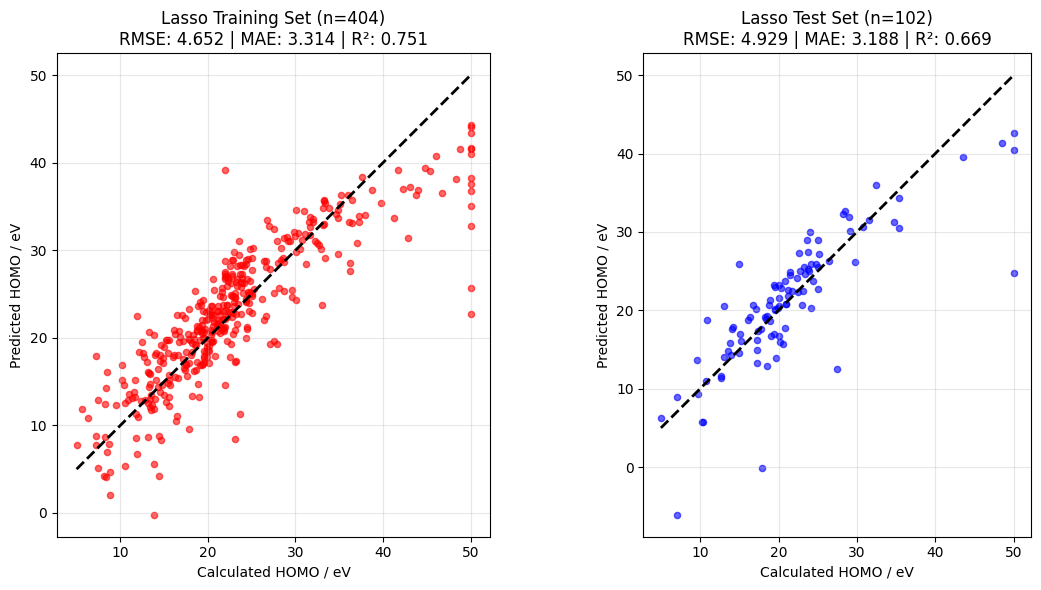

最適なalpha: 0.0001
選択された特徴量数: 13
削減された特徴量数: 0


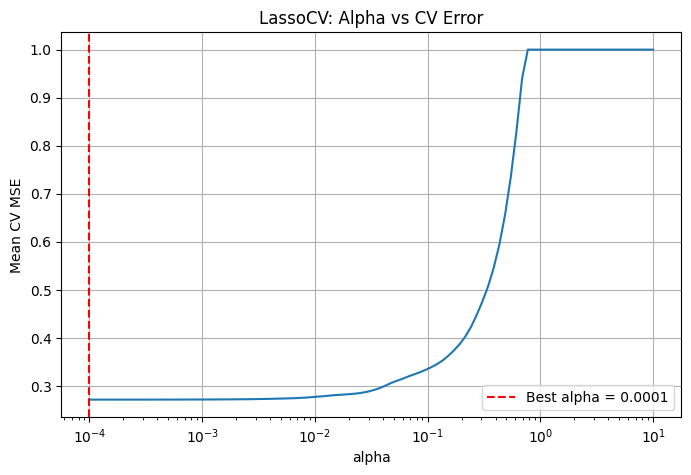

In [12]:
 #Lasso
#* Lassoの回帰モデルを準備します。回帰モデルとは、MEDVのような連続した数値を予測するためのモデルです。
model_name = 'Lasso'
model = linear_model.Lasso(alpha=0.0001)

#* 標準化したトレーニングデータを使って、モデルに学習させます。説明変数auto_X_trainから目的変数auto_y_trainを予測できるように、モデルが規則性を探します。
model.fit(auto_X_train,auto_y_train)

#* 学習に使ったトレーニングデータをモデルに入れて、HOMOの予測値を計算します。学習したデータに対してどれくらい合っているかを確認するためです。
autoscaled_pred_y_train = model.predict(auto_X_train)  
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean() #* モデルの予測値は標準化後の値なので、そのままでは元のHOMOの値として読みにくいです。そこで、標準化する前のHOMOの単位に戻しています。
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

#* 学習には使っていないテストデータをモデルに入れて、HOMOの予測値を計算します。これにより、未知のデータに対する予測性能を確認できます。
autoscaled_pred_y_test = model.predict(auto_X_test)  
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean() #* テストデータの予測値も標準化後の値なので、トレーニングデータと同じ基準を使って元のHOMOの単位に戻します。
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

pred_plot(y_train,pred_y_train,y_test,pred_y_test,model_name) #* トレーニングデータとテストデータについて、予測がどれくらい正確かを数値と散布図で確認します。

# 係数
coef = model.coef_

# alphaの探索範囲を 0.0001〜10 で対数スケールに設定（100点）
alphas = np.logspace(-4, 1, 100)   # 10^-4 = 0.0001 ～ 10^1 = 10

# LassoCVで交差検証しながら最適なalphaを探索
lasso_cv = LassoCV(
    alphas=alphas,     # 探索するalphaの範囲
    cv=5,              # 5分割交差検証
    random_state=42,
    max_iter=100000    # 収束しない場合に備えて多めに設定
)

# 標準化済みのトレーニングデータで学習
lasso_cv.fit(auto_X_train, auto_y_train)

# 結果の表示
print("最適なalpha:", lasso_cv.alpha_)

# 選択された特徴量数（係数が0でない）と削減された特徴量数（係数が0）
n_selected = (lasso_cv.coef_ != 0).sum()
n_removed  = (lasso_cv.coef_ == 0).sum()
print("選択された特徴量数:", n_selected)
print("削減された特徴量数:", n_removed)

# CV誤差（各alphaごとの平均MSE）をグラフ化
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cv.alphas_, mean_mse)
plt.axvline(
    lasso_cv.alpha_,
    linestyle='--',
    color='red',
    label=f'Best alpha = {lasso_cv.alpha_:.4f}'
)
plt.xlabel("alpha")
plt.ylabel("Mean CV MSE")
plt.title("LassoCV: Alpha vs CV Error")
plt.legend()
plt.grid(True)
plt.show()


第二回の宿題はここまでです。
余裕があればこの下もやってみてください。第3回で勉強する範囲です。

早期停止が実行されたイテレーション数: 145

MEGAN Training Set Performance:
Samples: 404 | RMSE: 1.6787 | MAE: 0.7500 | R²: 0.9676

MEGAN Test Set Performance:
Samples: 102 | RMSE: 3.7461 | MAE: 2.3153 | R²: 0.8086


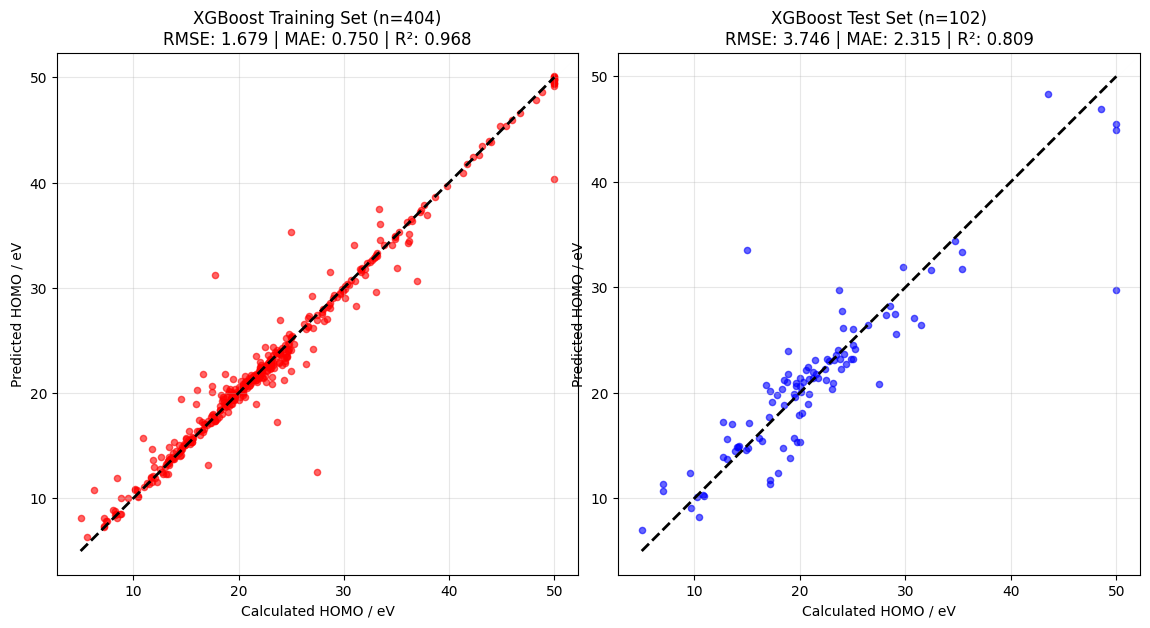

/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipykernel_54060/1082582053.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')


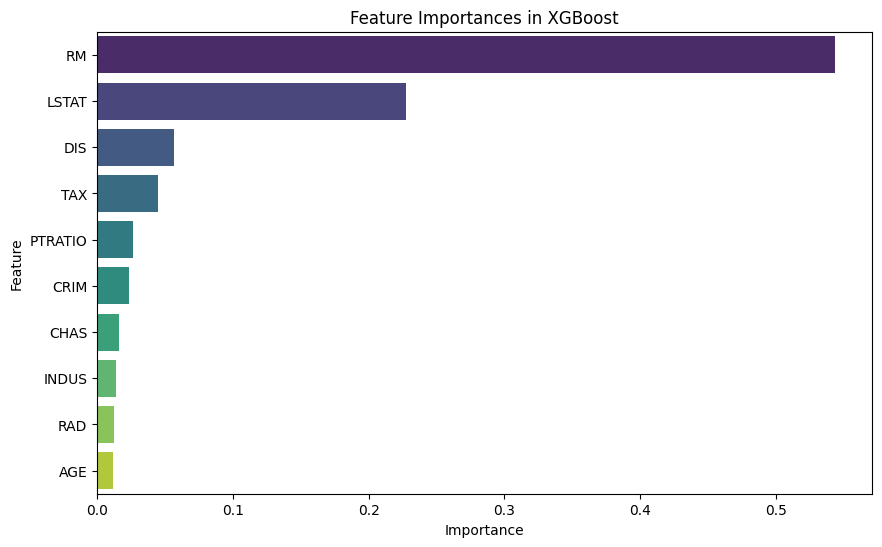

In [25]:
#* 早期停止を使うために、トレーニングデータの一部を検証データとして分けます。検証データは、学習の途中でモデルの性能が良くなっているかを確認するために使います。
model_name = 'XGBoost'
X_trainXGB, X_valid, y_trainXGB, y_valid = train_test_split(auto_X_train, auto_y_train, test_size=0.2, shuffle=True,random_state=42)

model = model = xgb.XGBRegressor(
    n_estimators=10000, 
    learning_rate=0.05,
    random_state=42,
    eval_metric='rmse',  
    early_stopping_rounds=50, 
)
model.fit(
    X_trainXGB,y_trainXGB,
    eval_set=[(X_valid,y_valid)],
    verbose=0
)
autoscaled_pred_y_train = model.predict(auto_X_train)  #* 早期停止を使って学習したモデルで、トレーニングデータのHOMOを予測します。
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean() #* 予測値は標準化された値として出てくるため、元のHOMOの単位に戻して、実際の値と比較できるようにします。
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

#* 早期停止によって、何回目の学習までが最もよかったと判断されたかを表示します。イテレーション数とは、モデルが学習を繰り返した回数のことです。
stopped_at = model.best_iteration
print(f"早期停止が実行されたイテレーション数: {stopped_at}")
#* 学習には使っていないテストデータに対して、早期停止を使ったモデルでHOMOを予測します。
autoscaled_pred_y_test = model.predict(auto_X_test)  #* 標準化したテストデータをモデルに入れて、標準化されたHOMOの予測値を計算します。
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean() #* テストデータの予測値も、実際のHOMOの値と比べられるように、標準化前の単位に戻します。
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

pred_plot(y_train,pred_y_train,y_test,pred_y_test,model_name) #* 早期停止を使ったモデルについて、予測の正確さを数値と散布図で確認します。
feature_importance(model,X_trainXGB,model_name) #* 早期停止を使って学習したモデルが、どの説明変数を重視したかを棒グラフで確認します。